In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

songs = pd.read_csv('dataset/songs.csv')

In [ ]:
filtered = songs[
    (songs['popularity'] > 0) &
    (songs['lyrics'].notna()) &
    (songs['lyrics'].str.strip() != '') &
    (songs['year'] <= 2023)
].copy().reset_index(drop=True)
print('Filtered songs (popularity > 0, non-empty lyrics, tracks from 2023 and below)')
print(f'Rows   : {len(filtered):,}')
print(f'Columns: {filtered.shape[1]}')
display(filtered.head(3))

In [ ]:
filtered.to_csv('filtered/songs_filtered.csv')

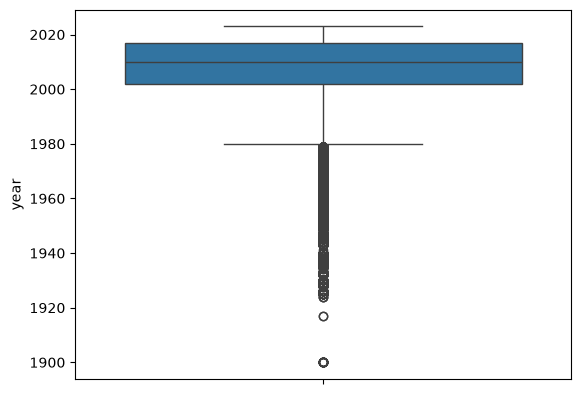

In [476]:
sns.boxplot(data=filtered, y='year')
plt.show()

In [ ]:
sns.violinplot(data=filtered[filtered['year'] >= 2000], y='year')
plt.show()

---
## 1. Year Range Comparisons

In [ ]:
year_ranges = ['2021-2023', '2016-2023', '2013-2023', '2010-2023', '2000-2023']
years_min = [2021, 2016, 2013, 2010, 2000]
cols = ['popularity', 'valence']

# filtering year ranges
filtered_list = []

for i, year in enumerate(years_min):
    filtered_list.append(filtered[filtered['year'] >= year].copy().reset_index(drop=True))
    print(f'\n({year_ranges[i]})\tRecords: {len(filtered_list[i]):,}')
    display(filtered_list[i][cols].describe())

In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20))

for i, (f, yr) in enumerate(zip(filtered_list, year_ranges)):

    ax_hist = axes[i, 0]   # left column  → valence distribution
    ax_scat = axes[i, 1]   # right column → valence vs popularity

    # ── Valence distribution ──────────────────────────────────────────────────
    ax_hist.hist(f['valence'], bins=40, color='orchid',
                 edgecolor='white', alpha=0.85)
    ax_hist.axvline(f['valence'].mean(), color='darkviolet',
                    linestyle='--',
                    label=f'Mean: {f["valence"].mean():.2f}')
    ax_hist.set_title(f'Valence Distribution ({yr})', fontweight='bold')
    ax_hist.set_xlabel('Valence (0 = negative, 1 = positive)')
    ax_hist.set_ylabel('Track Count')
    ax_hist.legend()

    # Valence vs Popularity scatter
    ax_scat.scatter(f['valence'], f['popularity'],
                    alpha=0.12, s=5, color='orchid')

    # Trend line so the relationship is easier to read
    z = np.polyfit(f['valence'], f['popularity'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(0, 1, 100)
    ax_scat.plot(x_line, p(x_line), color='darkviolet',
                 linewidth=1.5, linestyle='--',
                 label=f'r = {f["valence"].corr(f["popularity"]):.3f}')

    ax_scat.set_title(f'Valence vs Popularity ({yr})', fontweight='bold')
    ax_scat.set_xlabel('Valence')
    ax_scat.set_ylabel('Popularity')
    ax_scat.set_xlim(0, 1)
    ax_scat.legend()

plt.suptitle('Valence & Popularity by Year Range', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 2. Data Cleaning and Features

In [ ]:
for i, _ in enumerate(filtered_list):
    # lyrics
    filtered_list[i]['lyrics'] = filtered_list[i]['lyrics'].str.lower() \
                                    .str.encode('utf-8').str.decode('unicode_escape')
    
    # valence normalized
    filtered_list[i]['valence_norm'] = filtered_list[i]['valence'] * 2 - 1 

    # popularity logged
    filtered_list[i]['popularity_log'] = np.log1p(filtered_list[i]['popularity'])

In [ ]:
# lyrics and valence check
print('=== BEFORE ===')
print(filtered['lyrics'][0][:300])

print('\n=== AFTER ===')
print(filtered_list[1]['lyrics'][0][:300])

for i, f in enumerate(filtered_list):
    print(f'\n({year_ranges[i]})')
    display(f[['valence', 'valence_norm']].head())

In [ ]:
# log popularity check
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
bins = 20

for i, (f, yr) in enumerate(zip(filtered_list, year_ranges)):

    ax_pop = axes[i, 0]
    ax_pop_log = axes[i, 1]

    # Popularity distribution
    ax_pop.hist(f['popularity'], bins=bins, color='teal',
                 edgecolor='white', alpha=0.85)
    ax_pop.axvline(f['popularity'].mean(), color='darkslategray',
                    linestyle='--',
                    label=f'Mean: {f["popularity"].mean():.2f}')
    ax_pop.set_title(f'Popularity Distribution ({yr})', fontweight='bold')
    ax_pop.set_xlabel('Popularity (0 - 100)')
    ax_pop.set_ylabel('Track Count')
    ax_pop.legend()

    # Log Popularity
    ax_pop_log.hist(f['popularity_log'], bins=bins, color='teal',
                 edgecolor='white', alpha=0.85)
    ax_pop_log.axvline(f['popularity_log'].mean(), color='darkslategray',
                    linestyle='--',
                    label=f'Mean: {f["popularity_log"].mean():.2f}')
    ax_pop_log.set_title(f'Log Popularity Distribution ({yr})', fontweight='bold')
    ax_pop_log.set_ylabel('Track Count')
    ax_pop_log.legend()

plt.suptitle('Popularity vs Log Popularity by Year Range', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# check popularity outliers
fig, ax = plt.subplots(1, 5, figsize=(16, 6))
lower_whiskers = []
upper_whiskers = []

for i, (f, yr) in enumerate(zip(filtered_list, year_ranges)):
    bp_dict = ax[i].boxplot(f['popularity_log'])
    ax[i].set_title(f'({yr})', fontweight='bold')

    # Whiskers come in pairs per column: [lower_whisker, upper_whisker]
    whiskers = [whisker.get_ydata() for whisker in bp_dict["whiskers"]]

    # Get the values where the whiskers end
    lower_whiskers.append(whiskers[0][1])
    upper_whiskers.append(whiskers[1][1])

    print(f'({yr})')
    print(f"Lower Whisker End: {lower_whiskers[i]}")
    print(f"Upper Whisker End: {upper_whiskers[i]}")
    print()

plt.suptitle('Log Popularity Boxplots', fontsize=14, fontweight='bold')
plt.show()

In [477]:
# check pop log stats

for i, f in enumerate(filtered_list):
    print(f'({year_ranges[i]})')
    display(f['popularity_log'].describe())
    print('Coefficient of Variation (std / mean): ' + str(f['popularity_log'].std() / f['popularity_log'].mean()))
    print('Records below lower whisker: ' + str(len(f[f['popularity_log'] <= lower_whiskers[i]])))
    print('Records above upper whisker: ' + str(len(f[f['popularity_log'] >= upper_whiskers[i]])))
    print()

(2021–2023)


count    23667.000000
mean         3.456914
std          0.425269
min          2.484907
25%          3.178054
50%          3.496508
75%          3.784190
max          4.406719
Name: popularity_log, dtype: float64

Coefficient of Variation (std / mean): 0.12301987167506302
Records below lower whisker: 0
Records above upper whisker: 0

(2016–2023)


count    96345.000000
mean         3.358845
std          0.488768
min          2.197225
25%          3.044522
50%          3.433987
75%          3.737670
max          4.477337
Name: popularity_log, dtype: float64

Coefficient of Variation (std / mean): 0.14551675701745193
Records below lower whisker: 0
Records above upper whisker: 0

(2013-2023)


...

Coefficient of Variation (std / mean): 0.14847272525947705
Records below lower whisker: 0
Records above upper whisker: 0

(2010–2023)


count    162849.000000
mean          3.278494
std           0.521863
min           2.079442
25%           2.944439
50%           3.332205
75%           3.663562
max           4.499810
Name: popularity_log, dtype: float64

Coefficient of Variation (std / mean): 0.1591777434272773
Records below lower whisker: 0
Records above upper whisker: 0

(2000–2023)


count    254057.000000
mean          3.192424
std           0.564340
min           1.945910
25%           2.772589
50%           3.258097
75%           3.610918
max           4.499810
Name: popularity_log, dtype: float64

Coefficient of Variation (std / mean): 0.17677479386444933
Records below lower whisker: 0
Records above upper whisker: 0



In [ ]:
# removes outliers based on pop log
for i in range(len(filtered_list)):
    print(f'({year_ranges[i]})')

    print('OLD -> ' + str(len(filtered_list[i])))
    filtered_list[i] = filtered_list[i][filtered_list[i]['popularity_log'] > lower_whiskers[i]]
    filtered_list[i] = filtered_list[i][filtered_list[i]['popularity_log'] < upper_whiskers[i]]

    print('NEW -> ' + str(len(filtered_list[i])))
    print()

---
## 3. Saved Filters

In [ ]:
for i, f in enumerate(filtered_list):
    f.to_csv(f'filtered/songs_{year_ranges[i]}.csv')